# 🎯 损失函数（Loss Function）—— 深度学习的"指南针"

## 什么是损失函数？

**损失函数** 是一个衡量模型预测结果与真实标签之间差距的函数。数值越大，说明模型越"离谱"；数值越小，说明模型预测越准。

$$
\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N} \ell\big(f(x_i; \theta),\; y_i\big)
$$

其中 $\theta$ 是模型参数，$f(x_i; \theta)$ 是模型对第 $i$ 个样本的预测，$y_i$ 是真实标签，$\ell$ 是单个样本的损失。

## 为什么需要损失函数？

训练神经网络本质上是一个**优化问题**：

> **目标**：找到一组参数 $\theta^*$，使得损失函数的值最小

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$

损失函数就像**指南针**——梯度下降沿着损失函数下降最快的方向更新参数，一步步让模型变准。

## 三种最常见的损失函数

| 任务类型 | 损失函数 | 公式 | 适用场景 |
|:--------|:---------|:-----|:---------|
| **回归** | MSE（均方误差） | $\displaystyle \frac{1}{N}\sum (y - \hat{y})^2$ | 房价预测、温度预测等连续值 |
| **二分类** | BCE（二元交叉熵） | $\displaystyle -\frac{1}{N}\sum y\log\hat{y} + (1-y)\log(1-\hat{y})$ | 垃圾邮件检测、患病判断 |
| **多分类** | CrossEntropy（交叉熵） | $\displaystyle -\frac{1}{N}\sum\sum y_k\log\hat{y}_k$ | 手写数字识别、图像分类 |

## 核心直觉

```python
# 伪代码理解损失函数的作用
for 每轮训练:
    预测值 = 模型(输入数据)       # 前向传播
    损失值 = 损失函数(预测值, 真实值)  # 计算差距
    梯度 = 求导(损失值, 模型参数)      # 反向传播
    模型参数 -= 学习率 × 梯度         # 参数更新 → 损失变小
```

## 为什么不用"准确率"直接做损失函数？

准确率 $\frac{正确数}{总数}$ 的梯度几乎处处为 0（阶梯函数），无法用梯度下降优化。而 MSE、交叉熵等都是**光滑可导**的函数，梯度能顺畅地反向传播。

> **一句话总结**：损失函数是模型训练的"指挥棒"——它告诉模型往哪个方向调参，预测才能更接近真实值。


📐 四种损失函数计算对比

------------------------------------------------------------
1️⃣  MSE vs MAE —— 回归任务
------------------------------------------------------------
预测值        MSE (y-ŷ)²         MAE |y-ŷ|         
----------------------------------------------
0.0        9.0000             3.0000            
2.0        1.0000             1.0000            
3.0        0.0000             0.0000            
4.0        1.0000             1.0000            
6.0        9.0000             3.0000            

------------------------------------------------------------
2️⃣  BCE（二元交叉熵）—— 二分类任务
------------------------------------------------------------
预测概率         BCE 损失 -log(ŷ)      
--------------------------------
0.01         4.6052              
0.30         1.2040              
0.50         0.6931              
0.70         0.3567              
0.99         0.0101              

------------------------------------------------------------
3️⃣  CrossEntropy（交叉熵）—— 多分类任务
----------------------

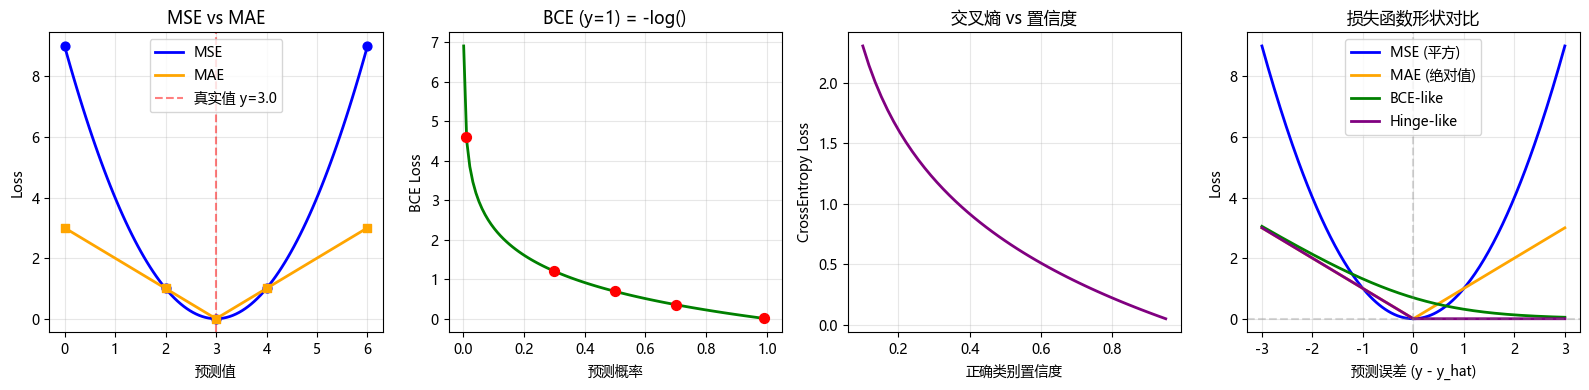


📊 四种损失函数总结
损失函数               预测完美时            预测极差时                特点
----------------------------------------------------------------------------
MSE                0                无上界(平方增长)            对离群点敏感
MAE                0                无上界(线性增长)            对离群点鲁棒
BCE                趋近0              log爆炸(无穷)            惩罚盲目自信
CrossEntropy       趋近0              log爆炸(无穷)            配合softmax

关键洞察:
  MSE vs MAE: 误差=2时, MSE=4, MAE=2 -> MSE对离群点惩罚更大
  MAE 梯度恒为 +/-1, MSE 梯度正比于误差 -> MSE越远拉得越狠
  BCE 适合概率输出, 对盲目自信的错判惩罚极大
  交叉熵适合多分类, 配合 softmax 输出概率分布


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ===== 设置中文字体 =====
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print("=" * 60)
print("📐 四种损失函数计算对比")
print("=" * 60)

# ===== 1. MSE vs MAE（回归任务） =====
print("\n" + "-" * 60)
print("1️⃣  MSE vs MAE —— 回归任务")
print("-" * 60)

# 假设：真实值 y=3，模型预测从 0 到 6
y_true = torch.tensor(3.0)
y_pred_range = torch.linspace(0, 6, 100)
mse_values = (y_pred_range - y_true) ** 2
mae_values = torch.abs(y_pred_range - y_true)

# 取几个典型预测值演示
test_preds = [0.0, 2.0, 3.0, 4.0, 6.0]
print(f"{'预测值':<10} {'MSE (y-ŷ)²':<18} {'MAE |y-ŷ|':<18}")
print("-" * 46)
for p in test_preds:
    mse_loss = (p - y_true.item()) ** 2
    mae_loss = abs(p - y_true.item())
    print(f"{p:<10.1f} {mse_loss:<18.4f} {mae_loss:<18.4f}")

# 画图：MSE vs MAE 曲线对比
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(y_pred_range.numpy(), mse_values.numpy(), 'b-', linewidth=2, label='MSE')
plt.plot(y_pred_range.numpy(), mae_values.numpy(), 'orange', linewidth=2, label='MAE')
plt.axvline(y_true.item(), color='r', linestyle='--', alpha=0.5, label=f'真实值 y={y_true.item()}')
plt.scatter(test_preds, [(p - y_true.item())**2 for p in test_preds], 
            color='blue', s=40, zorder=5)
plt.scatter(test_preds, [abs(p - y_true.item()) for p in test_preds], 
            color='orange', s=40, zorder=5, marker='s')
plt.xlabel('预测值')
plt.ylabel('Loss')
plt.title('MSE vs MAE')
plt.legend()
plt.grid(alpha=0.3)

# ===== 2. BCE（二元交叉熵）—— 二分类 =====
print("\n" + "-" * 60)
print("2️⃣  BCE（二元交叉熵）—— 二分类任务")
print("-" * 60)

# 真实标签 y=1，模型预测概率从 0 到 1
y_true_bin = torch.tensor(1.0)
p_pred = torch.linspace(0.001, 0.999, 100)  # 避免 log(0)
bce_values = -(y_true_bin * torch.log(p_pred) + (1 - y_true_bin) * torch.log(1 - p_pred))

test_probs = [0.01, 0.3, 0.5, 0.7, 0.99]
print(f"{'预测概率':<12} {'BCE 损失 -log(ŷ)':<20}")
print("-" * 32)
for p in test_probs:
    loss = -np.log(p) if y_true_bin.item() == 1 else -np.log(1 - p)
    print(f"{p:<12.2f} {loss:<20.4f}")

plt.subplot(1, 4, 2)
plt.plot(p_pred.numpy(), bce_values.numpy(), 'g-', linewidth=2)
plt.scatter(test_probs, [-np.log(p) for p in test_probs], 
            color='red', s=50, zorder=5)
plt.xlabel('预测概率')
plt.ylabel('BCE Loss')
plt.title('BCE (y=1) = -log()')
plt.grid(alpha=0.3)

# ===== 3. CrossEntropy（交叉熵）—— 多分类 =====
print("\n" + "-" * 60)
print("3️⃣  CrossEntropy（交叉熵）—— 多分类任务")
print("-" * 60)

# 假设：5 分类，真实类别是第 2 类（索引从 0 开始）
y_true_cls = torch.tensor([0, 1, 0, 0, 0], dtype=torch.float32)

# 三种预测情况：自信正确 / 模糊 / 自信错误
cases = {
    "正确自信": [0.05, 0.85, 0.03, 0.04, 0.03],
    "犹豫不决": [0.20, 0.35, 0.15, 0.18, 0.12],
    "错误自信": [0.80, 0.05, 0.05, 0.05, 0.05],
}

print(f"{'情况':<12} {'预测分布':<50} {'损失':<10}")
print("-" * 72)
for name, probs in cases.items():
    probs_t = torch.tensor(probs)
    loss = -torch.sum(y_true_cls * torch.log(probs_t))
    probs_str = "[" + ", ".join(f"{p:.2f}" for p in probs) + "]"
    print(f"{name:<12} {probs_str:<50} {loss.item():<10.4f}")

# 画 CrossEntropy 随正确类别置信度的变化
confidence = torch.linspace(0.1, 0.95, 50)
ce_values = []
for c in confidence:
    # 将 c 分配给正确类别，其余均匀分配
    remaining = (1 - c) / 4
    probs = torch.tensor([remaining, c, remaining, remaining, remaining])
    loss = -torch.sum(y_true_cls * torch.log(probs))
    ce_values.append(loss.item())

plt.subplot(1, 4, 3)
plt.plot(confidence.numpy(), ce_values, 'purple', linewidth=2)
plt.xlabel('正确类别置信度')
plt.ylabel('CrossEntropy Loss')
plt.title('交叉熵 vs 置信度')
plt.grid(alpha=0.3)

# ===== 4. 四种损失同框对比 =====
print("\n" + "-" * 60)
print("4️⃣  四种损失函数同框对比")
print("-" * 60)

x = np.linspace(-3, 3, 200)
plt.subplot(1, 4, 4)
plt.plot(x, x**2, 'b-', linewidth=2, label='MSE (平方)')
plt.plot(x, np.abs(x), 'orange', linewidth=2, label='MAE (绝对值)')
plt.plot(x, np.log(1 + np.exp(-x)), 'g-', linewidth=2, label='BCE-like')
plt.plot(x, np.where(x > 0, 0, -x), 'purple', linewidth=2, label='Hinge-like')
plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(0, color='gray', linestyle='--', alpha=0.3)
plt.xlabel('预测误差 (y - y_hat)')
plt.ylabel('Loss')
plt.title('损失函数形状对比')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===== 总结对比 =====
print("\n" + "=" * 60)
print("📊 四种损失函数总结")
print("=" * 60)
print(f"{'损失函数':<18} {'预测完美时':<16} {'预测极差时':<20} {'特点'}")
print("-" * 76)
print(f"{'MSE':<18} {'0':<16} {'无上界(平方增长)':<20} {'对离群点敏感'}")
print(f"{'MAE':<18} {'0':<16} {'无上界(线性增长)':<20} {'对离群点鲁棒'}")
print(f"{'BCE':<18} {'趋近0':<16} {'log爆炸(无穷)':<20} {'惩罚盲目自信'}")
print(f"{'CrossEntropy':<18} {'趋近0':<16} {'log爆炸(无穷)':<20} {'配合softmax'}")
print()
print("关键洞察:")
print("  MSE vs MAE: 误差=2时, MSE=4, MAE=2 -> MSE对离群点惩罚更大")
print("  MAE 梯度恒为 +/-1, MSE 梯度正比于误差 -> MSE越远拉得越狠")
print("  BCE 适合概率输出, 对盲目自信的错判惩罚极大")
print("  交叉熵适合多分类, 配合 softmax 输出概率分布")

In [2]:
import pandas as pd
import numpy as np

print("=" * 50)
print("📦 Pandas 两种核心数据结构")
print("=" * 50)

# ===== 1. Series（一维序列） =====
print("\n" + "-" * 50)
print("1️⃣  Series —— 带标签的一维数组")
print("-" * 50)

# 从列表创建
s1 = pd.Series([11, 22, 33, 44, 55])
print("从列表创建:")
print(s1)
print(f"  值:      {s1.values}")
print(f"  索引:    {s1.index.tolist()}")
print(f"  形状:    {s1.shape}")
print()

# 指定索引
s2 = pd.Series([85, 92, 78, 96], index=['张三', '李四', '王五', '赵六'])
print("指定索引 (姓名 → 分数):")
print(s2)
print(f"  张三的分数: {s2['张三']}")
print(f"  平均分:     {s2.mean():.1f}")
print()

# 从字典创建
scores = {'语文': 88, '数学': 95, '英语': 72, '物理': 90}
s3 = pd.Series(scores)
print("从字典创建:")
print(s3)
print(f"  最高分: {s3.max()}, 最低分: {s3.min()}")
print()

# ===== 2. DataFrame（二维表格） =====
print("\n" + "-" * 50)
print("2️⃣  DataFrame —— 二维表格型数据结构")
print("-" * 50)

# 从字典创建
data = {
    '姓名': ['张三', '李四', '王五', '赵六'],
    '年龄': [20, 21, 19, 22],
    '成绩': [85, 92, 78, 96],
    '是否通过': [True, True, False, True],
}
df = pd.DataFrame(data)
print("从字典创建 DataFrame:")
print(df)
print()

# 查看基本信息
print(f"形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")
print(f"数据类型:\n{df.dtypes}")
print()

# 从 NumPy 数组创建
arr = np.random.randn(4, 3)
df2 = pd.DataFrame(arr, columns=['特征A', '特征B', '特征C'])
print("从 NumPy 数组创建:")
print(df2)
print()

# ===== 3. DataFrame 基本操作 =====
print("\n" + "-" * 50)
print("3️⃣  DataFrame 基本操作")
print("-" * 50)

print("取 '成绩' 列:")
print(df['成绩'])
print()

print("取第 0~2 行 (iloc):")
print(df.iloc[0:3])
print()

print("成绩 > 80 的同学:")
print(df[df['成绩'] > 80])
print()

print("描述性统计:")
print(df.describe())
print()

# ===== 4. Series 和 DataFrame 的关系 =====
print("\n" + "-" * 50)
print("4️⃣  Series ≈ DataFrame 的一列")
print("-" * 50)

print("df['成绩'] 的类型:", type(df['成绩']))
print("它就是一个 Series!")
print()
print("取多列返回 DataFrame:")
print(df[['姓名', '成绩']].head(2))
print()

# ===== 总结 =====
print("=" * 50)
print("📊 总结")
print("=" * 50)
print(f"{'数据结构':<20} {'维度':<10} {'说明'}")
print("-" * 50)
print(f"{'Series':<20} {'1D':<10} {'带标签的一维数组，类似字典+列表'}")
print(f"{'DataFrame':<20} {'2D':<10} {'表格型数据，由多个 Series 组成'}")
print()
print("💡 DataFrame 可以理解成: 一组 Series 共用一个行索引")
print("   Series 可以理解成: 带索引的一维 NumPy 数组")

📦 Pandas 两种核心数据结构

--------------------------------------------------
1️⃣  Series —— 带标签的一维数组
--------------------------------------------------
从列表创建:
0    11
1    22
2    33
3    44
4    55
dtype: int64
  值:      [11 22 33 44 55]
  索引:    [0, 1, 2, 3, 4]
  形状:    (5,)

指定索引 (姓名 → 分数):
张三    85
李四    92
王五    78
赵六    96
dtype: int64
  张三的分数: 85
  平均分:     87.8

从字典创建:
语文    88
数学    95
英语    72
物理    90
dtype: int64
  最高分: 95, 最低分: 72


--------------------------------------------------
2️⃣  DataFrame —— 二维表格型数据结构
--------------------------------------------------
从字典创建 DataFrame:
   姓名  年龄  成绩   是否通过
0  张三  20  85   True
1  李四  21  92   True
2  王五  19  78  False
3  赵六  22  96   True

形状: (4, 4)
列名: ['姓名', '年龄', '成绩', '是否通过']
数据类型:
姓名      object
年龄       int64
成绩       int64
是否通过      bool
dtype: object

从 NumPy 数组创建:
        特征A       特征B       特征C
0 -1.783783 -0.649587  0.316857
1  0.455062 -0.517016 -0.428926
2 -0.674222  0.274212  1.302632
3 -0.022884  0.551621  0.252067


-----